In [23]:
import pandas as pd
import os

from Bio import Entrez
from Bio.Entrez import efetch

from tqdm import tqdm

from dotenv import load_dotenv
load_dotenv(override=True)

email = os.getenv("ENTREZ_EMAIL")
Entrez.email = email


In [24]:
def get_pub_date(pmid):
    """
    Get publication date from PubMed using PMID.

    :param pmid: PubMed ID
    :return: Publication date in the format {'Year': 'YYYY', 'Month': 'MM', 'Day': 'DD'} or None if not available
    """
    if not isinstance(pmid, int):
        pmid = int(pmid)
    try:
        handle = efetch(db="pubmed", id=pmid, retmode="xml")
        record = Entrez.read(handle)
        handle.close()
        pub_date = record["PubmedArticle"][0]["MedlineCitation"]["Article"]["Journal"]["JournalIssue"]["PubDate"]
        return pub_date
    except Exception as e:
        print(f"Error retrieving PMID {pmid}: {e}")
        return None

# test
print(get_pub_date(20377413))

{'Year': '2010', 'Month': 'May', 'Day': '15'}


# RCT Summarization data

Source: https://github.com/bwallace/RCT-summarization-data

**NOTE**

- The abstracts of each RCT do not include the section headers.
- The inputs may not be the full list of RCTs. Some RCTs may be missing.

*Make sure to download the github repo within the local "data" directory before running the below cells.*

In [ ]:
# TARGET DATA
# the targets are taken as the "Author Conclusions" section from the abstracts of Cochrane 
# (https://www.cochranelibrary.com/) evidence syntheses 

# Load target data from CSV files
train_target_file_path = "./RCT-summarization-data/train-targets.csv"
dev_target_file_path = "./RCT-summarization-data/dev-targets.csv"
test_target_file_path = "./RCT-summarization-data/test-targets.csv"

train_target = pd.read_csv(train_target_file_path)
dev_target = pd.read_csv(dev_target_file_path)
test_target = pd.read_csv(test_target_file_path)

print(f"train_target: {len(train_target)}")
print(f"dev_target: {len(dev_target)}")
print(f"test_target: {len(test_target)}")

# Combine all target dataframes into one
cochrane_data_target = pd.concat([train_target, dev_target, test_target], ignore_index=True)
# We won't be using the 'Unnamed: 0' column, so we drop it
cochrane_data_target = cochrane_data_target.drop(columns=["Unnamed: 0"])
print(f"cochrane_data_target: {len(cochrane_data_target)}")

cochrane_data_target.head()

In [ ]:
# INPUT DATA
# The inputs are titles and abstracts of articles describing randomized controlled trials (RCTs)

# Load input data from CSV files
train_input_file_path = "./RCT-summarization-data/train-inputs.csv"
dev_input_file_path = "./RCT-summarization-data/dev-inputs.csv"
test_input_file_path = "./RCT-summarization-data/test-inputs.csv"

train_input = pd.read_csv(train_input_file_path)
dev_input = pd.read_csv(dev_input_file_path)
test_input = pd.read_csv(test_input_file_path)

print(f"train_input: {len(train_input)}")
print(f"dev_input: {len(dev_input)}")
print(f"test_input: {len(test_input)}")

# Combine all input dataframes into one
cochrane_data_input = pd.concat([train_input, dev_input, test_input], ignore_index=True)
# We won't be using the 'Unnamed: 0' column, so we drop it
cochrane_data_input = cochrane_data_input.drop(columns=["Unnamed: 0"])
print(f"cochrane_data_input: {len(cochrane_data_input)}")

cochrane_data_input.head()

train_input: 40497
dev_input: 5033
test_input: 5678
cochrane_data_input: 51208


,ReviewID,PMID,Title,Abstract
0,CD007697,16394043,Aggressive surgical effort and improved surviv...,Residual disease after initial surgery for ova...
1,CD000174,8627434,Prophylactic indomethacin therapy in the first...,To determine whether a course of low-dose indo...
2,CD000174,2677294,Indomethacin reduces the risks of severe intra...,"A prospective, random selection, double-blind ..."
3,CD000174,3373404,Administration of indomethacin for the prevent...,One hundred twenty-two preterm infants were en...
4,CD000174,3321891,Early intravenous indomethacin prolongs respir...,Infants weighing 1500 g at birth requiring eit...


Add the publication date to each RCT article using the PubMed API.

This takes a bit of time so please be patient...

In [ ]:
# use tqdm to show progress
tqdm.pandas(desc="Retrieving publication dates")

# Apply the get_pub_date function to the PMID column and create a new PubDate column
cochrane_data_input["PubDate"] = cochrane_data_input["PMID"].progress_apply(get_pub_date)

In [ ]:
cochrane_data_input.head()

,ReviewID,PMID,Title,Abstract,PubDate
0,CD007697,16394043,Aggressive surgical effort and improved surviv...,Residual disease after initial surgery for ova...,"{'Year': '2006', 'Month': 'Jan'}"
1,CD000174,8627434,Prophylactic indomethacin therapy in the first...,To determine whether a course of low-dose indo...,"{'Year': '1996', 'Month': 'May'}"
2,CD000174,2677294,Indomethacin reduces the risks of severe intra...,"A prospective, random selection, double-blind ...","{'Year': '1989', 'Month': 'Oct'}"
3,CD000174,3373404,Administration of indomethacin for the prevent...,One hundred twenty-two preterm infants were en...,"{'Year': '1988', 'Month': 'Jun'}"
4,CD000174,3321891,Early intravenous indomethacin prolongs respir...,Infants weighing 1500 g at birth requiring eit...,"{'Year': '1987', 'Month': 'Nov'}"


In [ ]:
# save the cochrane_data_input data to a json file
cochrane_data_input_file_path = "./cochrane_review_data_inputs.jsonl"
cochrane_data_input.to_json(cochrane_data_input_file_path, orient="records", lines=True)
print(f"cochrane review input data saved to {cochrane_data_input_file_path}")

# save the cochrane_data_target data to a json file
cochrane_data_target_file_path = "./cochrane_review_data_targets.jsonl"
cochrane_data_target.to_json(cochrane_data_target_file_path, orient="records", lines=True)
print(f"cochrane review target data saved to {cochrane_data_target_file_path}")

# Simplification Data

Source: https://github.com/AshOlogn/Paragraph-level-Simplification-of-Medical-Texts

**NOTE**

- This is where we will get the full review title and abstract since Summarization Data above only include Author's Conclusion section of each Cochrane Review abstract

*Make sure to download the github repo (specifically the "data" folder) within the local "data" directory before running the below cells.*

In [ ]:
# Cochrane simplification data
simplification_data_file_path = "./Paragraph-level-Simplification-of-Medical-Texts/data.json"
simplification_data = pd.read_json(simplification_data_file_path)

simplification_data.head()

Get the Cochrane ID from the DOI

In [ ]:
# Get DOI column only
simplification_data_doi = simplification_data[["doi"]]
print(f"simplification data: {len(simplification_data_doi)}")

# Remove any duplicates
simplification_data_doi = simplification_data_doi.drop_duplicates()
simplification_data_doi = simplification_data_doi.reset_index(drop=True)
print(f"simplification data after removing duplicates: {len(simplification_data_doi)}")

# Get only the Cochrane ID from the DOI
# split the DOI column on the slash, take the last part, split on the dot, take the second part
simplification_data_doi["doi_slash"] = simplification_data_doi["doi"].str.split("/").str[-1]
simplification_data_doi["cochrane_id"] = simplification_data_doi["doi_slash"].str.split(".").str[1]

# drop the doi_slash column (helper column)
simplification_data_doi = simplification_data_doi.drop(columns=["doi_slash"])

simplification_data_doi.head()


simplification data: 7816
simplification data after removing duplicates: 7816


,doi,cochrane_id
0,10.1002/14651858.CD009997.pub2,CD009997
1,10.1002/14651858.CD006553.pub3,CD006553
2,10.1002/14651858.CD004078.pub2,CD004078
3,10.1002/14651858.CD003957.pub2,CD003957
4,10.1002/14651858.CD003798.pub2,CD003798


In [ ]:
# add cochrane_id to the simplification_data
# merge the simplification_data_doi with the simplification_data on the doi column
simplification_data = simplification_data.merge(simplification_data_doi, left_on="doi", right_on="doi", how="inner")

simplification_data.head()

,doi,name,free,abstract,pls_title,pls_type,pls,cochrane_id
0,10.1002/14651858.CD009997.pub2,Intermittent oral iron supplementation during ...,True,"[{'heading': 'Background', 'text': 'Anaemia is...",Intermittent regimens of iron supplementation ...,long,Anaemia is a frequent condition during pregnan...,CD009997
1,10.1002/14651858.CD006553.pub3,Planned caesarean section for women with a twi...,True,"[{'heading': 'Background', 'text': 'Twin pregn...",Planned caesarean section for a twin pregnancy,long,The incidence of twins varies considerably bet...,CD006553
2,10.1002/14651858.CD004078.pub2,Postoperative adjuvant chemotherapy in rectal ...,True,"[{'heading': 'Background', 'text': 'Colorectal...",Postoperative adjuvant chemotherapy in rectal ...,long,The use of chemotherapy after curative surgery...,CD004078
3,10.1002/14651858.CD003957.pub2,Prophylactic versus selective antibiotics for ...,True,"[{'heading': 'Background', 'text': 'Early onse...",Prophylactic versus selective antibiotics for ...,long,Several factors increase the risk of serious i...,CD003957
4,10.1002/14651858.CD003798.pub2,Specialist outreach clinics in primary care an...,True,"[{'heading': 'Background', 'text': 'Specialist...",Specialist outreach clinics in primary care an...,long,This review examines the benefits and costs of...,CD003798


# Pre-processing Data

Combine Input, Target, and Review Abstract from Simplification Data into One Dataset

In [ ]:
cochrane_data_input_file_path = "./cochrane_review_data_inputs.jsonl"
cochrane_data_target_file_path = "./cochrane_review_data_targets.jsonl"
# load the cochrane_data_input and cochrane_data_target data from json files
cochrane_data_input = pd.read_json(cochrane_data_input_file_path, orient="records", lines=True)
cochrane_data_target = pd.read_json(cochrane_data_target_file_path, orient="records", lines=True)

In [ ]:
cochrane_data = cochrane_data_target.copy()

In [ ]:
# For each row in cochrane_data, get the corresponding number of rows in cochrane_data_input with the same ReviewID
cochrane_data["Inputs"] = cochrane_data["ReviewID"].apply(lambda x: cochrane_data_input[cochrane_data_input["ReviewID"] == x].to_dict(orient="records"))
cochrane_data["NumInputs"] = cochrane_data["Inputs"].apply(lambda x: len(x))
cochrane_data.head()

,ReviewID,Target,Inputs,NumInputs
0,CD007697,We found only low quality evidence comparing u...,"[{'ReviewID': 'CD007697', 'PMID': 16394043, 'T...",1
1,CD000174,Prophylactic indomethacin has short-term benef...,"[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14
2,CD008805,First aid for phosphorus burns involves the co...,"[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2
3,CD000248,"Compared with control, there was no evidence o...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4
4,CD004431,The diversity of psychological interventions i...,"[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13


In [ ]:
# Remove reviews with Inputs that have any of PMIDs without PubDate
# This is to ensure that we only keep reviews with valid publication dates
print(f"Number of reviews before removing those with invalid PubDate: {len(cochrane_data)}")
pmids_without_pubdate = [3369327, 18176319, 8019309, 7982870, 9756679, 12237786]
cochrane_data = cochrane_data[~cochrane_data["Inputs"].apply(lambda x: any(input.get("PMID") in pmids_without_pubdate for input in x))]
cochrane_data = cochrane_data.reset_index(drop=True)
print(f"number of reviews with valid publication dates: {len(cochrane_data)}")

Number of reviews before removing those with invalid PubDate: 4692
number of reviews with valid publication dates: 4685


In [ ]:
# STATISTICS

# get the average number of inputs per review
average_num_inputs = cochrane_data["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = cochrane_data["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = cochrane_data["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

# get the number of reviews with 1 input
num_reviews_with_1_input = cochrane_data[cochrane_data["NumInputs"] == 1].shape[0]
print(f"number of reviews with 1 input: {num_reviews_with_1_input}")

average number of inputs per review: 10.88708644610459
maximum number of inputs per review: 537
minimum number of inputs per review: 1
number of reviews with 1 input: 526


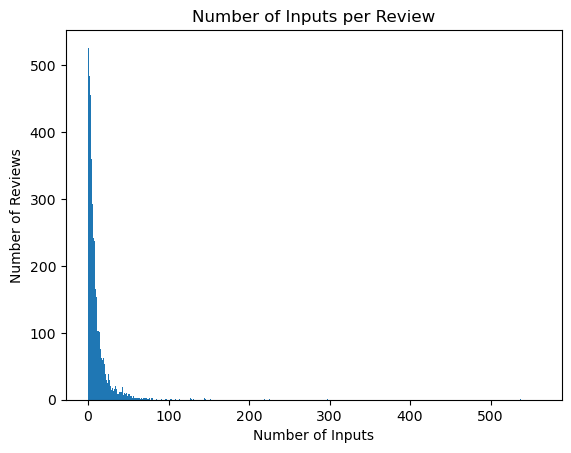

In [ ]:
# create a histogram of the number of inputs per review
import matplotlib.pyplot as plt

plt.hist(cochrane_data["NumInputs"], bins=range(1, max_num_inputs + 25), align="left")
plt.xlabel("Number of Inputs")
plt.ylabel("Number of Reviews")
plt.title("Number of Inputs per Review")

plt.show()

In [ ]:
# grab ReviewID of the reviews with 50+ inputs
cochrane_data_50_inputs = cochrane_data[cochrane_data["NumInputs"] > 50]
cochrane_data_50_inputs = cochrane_data_50_inputs.reset_index(drop=True)
print(f"number of reviews with 50+ inputs: {len(cochrane_data_50_inputs)}")

# # just grab the ReviewID and NumInputs columns
# cochrane_data_50_inputs = cochrane_data_50_inputs[["ReviewID", "NumInputs"]]
# cochrane_data_50_inputs = cochrane_data_50_inputs.reset_index(drop=True)

# # save to jsonl
# cochrane_data_50_inputs_file_path = "./cochrane_review_data_50_inputs_list.jsonl"
# cochrane_data_50_inputs.to_json(cochrane_data_50_inputs_file_path, orient="records", lines=True)

number of reviews with 50+ inputs: 101


In [ ]:
# remove rows with 50+ inputs from the cochrane_data data
cochrane_data = cochrane_data[cochrane_data["NumInputs"] <= 50]
# remove rows with 1 input from the cochrane_data data
cochrane_data = cochrane_data[cochrane_data["NumInputs"] > 1]
cochrane_data = cochrane_data.reset_index(drop=True)
print(f"number of reviews with more than 1 input but less than or equal 50 inputs: {len(cochrane_data)}")

number of reviews with more than 1 input but less than or equal 50 inputs: 4058


In [ ]:
# merge the simplification_data with the cochrane_data data
cochrane_data_merged = cochrane_data.merge(simplification_data, left_on="ReviewID", right_on="cochrane_id", how="inner")
print(f"cochrane_data after merging with simplification data: {len(cochrane_data_merged)}")

# rename the columns doi to DOI and drop cochrane_id
cochrane_data_merged = cochrane_data_merged.rename(columns={"doi": "DOI"})
cochrane_data_merged = cochrane_data_merged.drop(columns=["cochrane_id"])

cochrane_data_merged.head()

In [ ]:
# Cleaning up columns

# Remove the following columns from the cochrane_data_target_merged data: "Target", "free" 
cochrane_data_merged = cochrane_data_merged.drop(columns=["Target", "free", "pls_title", "pls_type", "pls"])

# rename the columns to match the case formatting
cochrane_data_merged = cochrane_data_merged.rename(columns={
    "name": "ReviewTitle",
    "abstract": "ReviewAbstract",
})

# reorder the columns to match the desired output
cochrane_data_merged = cochrane_data_merged[[
    "DOI",
    "ReviewID",
    "ReviewTitle",
    "ReviewAbstract",
    "Inputs",
    "NumInputs"
]]

print(f"Final number of reviews in data: {len(cochrane_data_merged)}")

cochrane_data_merged.head()

Final number of reviews in data: 3913


,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs
0,10.1002/14651858.CD000174.pub2,CD000174,Prophylactic intravenous indomethacin for prev...,"[{'heading': 'Background', 'text': 'Persistent...","[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14
1,10.1002/14651858.CD008805.pub3,CD008805,Interventions for treating phosphorus burns,"[{'heading': 'Background', 'text': 'Phosphorus...","[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2
2,10.1002/14651858.CD000248.pub2,CD000248,Anticoagulants for preventing recurrence follo...,"[{'heading': 'Background', 'text': 'After a fi...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4
3,10.1002/14651858.CD004431.pub2,CD004431,Psychological interventions for multiple scler...,"[{'heading': 'Background', 'text': 'The unpred...","[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13
4,10.1002/14651858.CD008039.pub3,CD008039,Ibuprofen with or without an antiemetic for ac...,"[{'heading': 'Background', 'text': 'This is an...","[{'ReviewID': 'CD008039', 'PMID': 11554954, 'T...",8


In [ ]:
# STATISTICS
# get the average number of inputs per review
average_num_inputs = cochrane_data_merged["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = cochrane_data_merged["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = cochrane_data_merged["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

average number of inputs per review: 10.346537183746486
maximum number of inputs per review: 50
minimum number of inputs per review: 2


## Intervention Reviews

Use a list of intervention reviews list exported from Cochrane Library (December 1, 2025) to filter out any non-intervention reviews in our dataset.

In [ ]:
# load the citations from the cochrane-intervention-reviews-20251201.csv
citations_file_path = "./cochrane-intervention-reviews-20251201.csv"
citations = pd.read_csv(citations_file_path)
print(f"number of cochrane intervention reviews citations: {len(citations)}")
citations.head()

number of cochrane intervention reviews citations: 9116


,Cochrane Review ID,Author(s),Title,Source,Year,Abstract,Issue,Publisher,ISSN,Keywords,DOI,URL,Cochrane Review Group Code
0,CD015173.PUB2,"Aung, HH; Naing, C; Ni, H; Aye, SN; Htet, NH; ...",Human stem cells for decompensated cirrhosis i...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,"*Liver Cirrhosis [complications, mortality, su...",10.1002/14651858.CD015173.pub2,http://dx.doi.org/10.1002/14651858.CD015173.pub2,Central Editorial Service
1,CD015376.PUB2,"Vesentini, G; O'Connor, N; Le Berre, M; Nabhan...",Interventions for treating urinary incontinenc...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,NaN,10.1002/14651858.CD015376.pub2,http://dx.doi.org/10.1002/14651858.CD015376.pub2,Central Editorial Service
2,CD004143.PUB6,"Bofill Rodriguez, M; Yong, LN; Mirkov, S; Beko...",Long‐term hormone therapy for perimenopausal a...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,*Estrogen Replacement Therapy [adverse effects...,10.1002/14651858.CD004143.pub6,http://dx.doi.org/10.1002/14651858.CD004143.pub6,Central Editorial Service
3,CD015839.PUB2,"Darlison, P; Moresco, L; Nussbaumer-Streit, B;...",Decongestants and antihistamines for acute oti...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,"*Histamine Antagonists [adverse effects, thera...",10.1002/14651858.CD015839.pub2,http://dx.doi.org/10.1002/14651858.CD015839.pub2,Central Editorial Service
4,CD011852.PUB2,"de Rooij, JD; Verhagen, AP; Harhangi, BS; Fehl...",Nucleoplasty for cervical radicular pain due t...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,*Cervical Vertebrae [surgery]; *Intervertebral...,10.1002/14651858.CD011852.pub2,http://dx.doi.org/10.1002/14651858.CD011852.pub2,Central Editorial Service


In [ ]:
# filter the cochrane_data_merged to only include rows where the DOI is in the citations DOI column
cochrane_data_merged = cochrane_data_merged[cochrane_data_merged["DOI"].isin(citations["DOI"])]
cochrane_data_merged = cochrane_data_merged.reset_index(drop=True)
print(f"number of reviews in cochrane_data_merged after filtering with citations: {len(cochrane_data_merged)}")

number of reviews in cochrane_data_merged after filtering with citations: 3430


In [ ]:
# merge the cochrane_data with the citations on the DOI column to add Year and Keywords
cochrane_data_merged = cochrane_data_merged.merge(citations[["DOI", "Year", "Keywords"]], on="DOI", how="left")
cochrane_data_merged.head()

,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs,Year,Keywords
0,10.1002/14651858.CD000174.pub2,CD000174,Prophylactic intravenous indomethacin for prev...,"[{'heading': 'Background', 'text': 'Persistent...","[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14,2010,"*Infant, Very Low Birth Weight; Cardiovascular..."
1,10.1002/14651858.CD008805.pub3,CD008805,Interventions for treating phosphorus burns,"[{'heading': 'Background', 'text': 'Phosphorus...","[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2,2014,"*Phosphorus; Antidotes [adverse effects, *ther..."
2,10.1002/14651858.CD000248.pub2,CD000248,Anticoagulants for preventing recurrence follo...,"[{'heading': 'Background', 'text': 'After a fi...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4,2009,"Anticoagulants [adverse effects, *therapeutic ..."
3,10.1002/14651858.CD004431.pub2,CD004431,Psychological interventions for multiple scler...,"[{'heading': 'Background', 'text': 'The unpred...","[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13,2006,"*Adaptation, Psychological; Cognition Disorder..."
4,10.1002/14651858.CD008039.pub3,CD008039,Ibuprofen with or without an antiemetic for ac...,"[{'heading': 'Background', 'text': 'This is an...","[{'ReviewID': 'CD008039', 'PMID': 11554954, 'T...",8,2013,"Administration, Oral; Adult; Analgesics, Non‐N..."


In [ ]:
# get number of unique PubMedIDs in the Inputs
unique_pubmed_ids = set()
for inputs in cochrane_data_merged["Inputs"]:
    for input in inputs:
        pmid = input.get("PMID")
        if pmid:
            unique_pubmed_ids.add(pmid)

print(f"number of unique PubMedIDs in the Inputs: {len(unique_pubmed_ids)}")

number of unique PubMedIDs in the Inputs: 32181


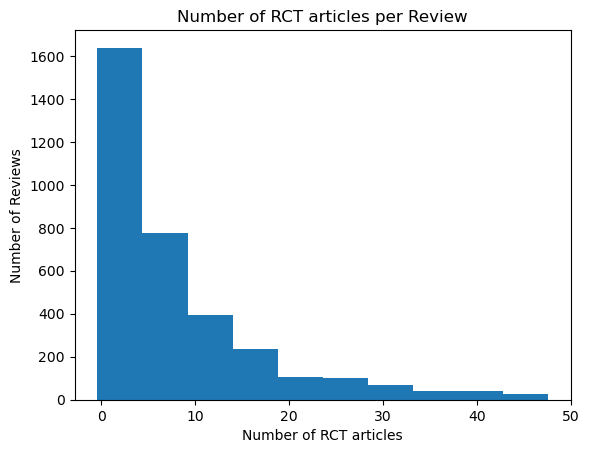

In [ ]:
# create a histogram of the number of inputs per review
import matplotlib.pyplot as plt

plt.hist(cochrane_data_merged["NumInputs"], align="left")
plt.xlabel("Number of RCT articles")
plt.ylabel("Number of Reviews")
plt.title("Number of RCT articles per Review")

# save the figure as PDF
# plt.savefig("num_rcts_per_review.pdf")

plt.show()

In [28]:
# get highest and lowest year from the Year column
years = cochrane_data_merged["Year"].astype(int)
highest_year = years.max()
lowest_year = years.min()
print(f"highest year in the data: {highest_year}")
print(f"lowest year in the data: {lowest_year}")

highest year in the data: 2020
lowest year in the data: 1997


In [ ]:
samples = pd.read_json("./cochrane_review_data_300_samples.json")

# how many match from cochrane_data_merged
matched_samples = samples[samples["ReviewID"].isin(cochrane_data_merged["ReviewID"])]
print(f"number of matched samples from cochrane_data_merged: {len(matched_samples)}")

number of matched samples from cochrane_data_merged: 269


In [ ]:
# save the cochrane_review_data data to a jsonl file
cochrane_data_file_path = "./cochrane_review_data.jsonl"
cochrane_data_merged.to_json(cochrane_data_file_path, orient="records", lines=True, force_ascii=False)
print(f"fully merged cochrane review data saved to {cochrane_data_file_path}")

fully merged cochrane review data saved to ./cochrane_review_data.jsonl


# Annotation (Number of Studies) - Check

In [29]:
import pandas as pd

ac_annotated = pd.read_json("cochrane_review_data_300_samples_ac_annotated.json")
print(f"number of annotated samples: {len(ac_annotated)}")
hl_annotated = pd.read_json("cochrane_review_data_300_samples_hl_annotated.json")
print(f"number of annotated samples: {len(hl_annotated)}")

number of annotated samples: 300
number of annotated samples: 300


In [30]:
# compare TrueNumStudies column from both dataframes and find mismatches
mismatches = []
for _, row in ac_annotated.iterrows():
    review_id = row["ReviewID"]
    true_num_studies_ac = row["TrueNumStudies"]
    true_num_studies_hl = hl_annotated[hl_annotated["ReviewID"] == review_id]["TrueNumStudies"].values
    if len(true_num_studies_hl) == 0:
        continue
    true_num_studies_hl = true_num_studies_hl[0]
    if true_num_studies_ac != true_num_studies_hl:
        mismatches.append((review_id, true_num_studies_ac, true_num_studies_hl))

In [32]:
# print mismatches
print(f"Mismatches in TrueNumStudies between AC and HL annotations: {len(mismatches)}")
for mismatch in mismatches:
    print(f"Mismatch for ReviewID {mismatch[0]}: AC TrueNumStudies = {mismatch[1]}, HL TrueNumStudies = {mismatch[2]}")

Mismatches in TrueNumStudies between AC and HL annotations: 13
Mismatch for ReviewID CD000512: AC TrueNumStudies = 5, HL TrueNumStudies = 4
Mismatch for ReviewID CD003545: AC TrueNumStudies = 50, HL TrueNumStudies = 13
Mismatch for ReviewID CD001244: AC TrueNumStudies = 41, HL TrueNumStudies = 36
Mismatch for ReviewID CD001990: AC TrueNumStudies = 5, HL TrueNumStudies = 6
Mismatch for ReviewID CD006148: AC TrueNumStudies = 19, HL TrueNumStudies = 17
Mismatch for ReviewID CD001860: AC TrueNumStudies = 26, HL TrueNumStudies = 14
Mismatch for ReviewID CD002760: AC TrueNumStudies = 4, HL TrueNumStudies = 52
Mismatch for ReviewID CD007712: AC TrueNumStudies = 4, HL TrueNumStudies = 3
Mismatch for ReviewID CD007400: AC TrueNumStudies = 39, HL TrueNumStudies = 5
Mismatch for ReviewID CD004251: AC TrueNumStudies = 20, HL TrueNumStudies = 22
Mismatch for ReviewID CD007045: AC TrueNumStudies = 2, HL TrueNumStudies = 1
Mismatch for ReviewID CD003869: AC TrueNumStudies = 54, HL TrueNumStudies = 10

# Web Scraping Evaluation Check

In [ ]:
import pandas as pd

ac_annotated_webscraping = pd.read_json("../code/outputs/extract_num_studies/cochrane_review_data_300_samples_ac_annotated_webscraping.json")
hl_annotated_webscraping = pd.read_json("../code/outputs/extract_num_studies/cochrane_review_data_300_samples_hl_annotated_webscraping.json")

In [2]:
def find_mismatches(df, column1, column2):
    mismatches = []
    for _, row in df.iterrows():
        val1 = row[column1]
        val2 = row[column2]
        if val1 != val2:
            mismatches.append((row["ReviewID"], val1, val2))
    return mismatches

def calculate_mean_absolute_error(first_list, second_list):
    '''
    Calculate Mean Absolute Error (MAE) between two different lists of numbers.
    In this case, first_list is annotated numbers and second_list is numbers from web scraping.
    '''
    assert len(first_list) == len(second_list)
    total = len(first_list)
    # remove None values from preds which can happen if model fails to extract a number
    absolute_errors = [abs(f - s) for f, s in zip(first_list, second_list)]
    mae = sum(absolute_errors) / total if total > 0 else 0 

    return {"mae": mae, "total": total}

In [21]:
ac_mismatches = find_mismatches(ac_annotated_webscraping, "TrueNumStudies", "NumIncludedStudies")
hl_mismatches = find_mismatches(hl_annotated_webscraping, "TrueNumStudies", "NumIncludedStudies")

In [22]:
print(f"Number of mismatches in AC annotations: {len(ac_mismatches)}")
print(f"Percentage of mismatches in AC annotations: {len(ac_mismatches) / len(ac_annotated_webscraping) * 100:.2f}%")
print(f"MSE in AC annotations: {calculate_mean_absolute_error(ac_annotated_webscraping['TrueNumStudies'].tolist(), ac_annotated_webscraping['NumIncludedStudies'].tolist())}")
for mismatch in ac_mismatches:
    print(f"AC Mismatch for ReviewID {mismatch[0]}: TrueNumStudies = {mismatch[1]}, NumIncludedStudies = {mismatch[2]}")

Number of mismatches in AC annotations: 35
Percentage of mismatches in AC annotations: 11.67%
MSE in AC annotations: {'mae': 0.36333333333333334, 'total': 300}
AC Mismatch for ReviewID CD006268: TrueNumStudies = 22, NumIncludedStudies = 23
AC Mismatch for ReviewID CD006055: TrueNumStudies = 24, NumIncludedStudies = 30
AC Mismatch for ReviewID CD007064: TrueNumStudies = 30, NumIncludedStudies = 33
AC Mismatch for ReviewID CD007961: TrueNumStudies = 9, NumIncludedStudies = 8
AC Mismatch for ReviewID CD000085: TrueNumStudies = 6, NumIncludedStudies = 9
AC Mismatch for ReviewID CD003887: TrueNumStudies = 4, NumIncludedStudies = 5
AC Mismatch for ReviewID CD006211: TrueNumStudies = 29, NumIncludedStudies = 31
AC Mismatch for ReviewID CD002300: TrueNumStudies = 10, NumIncludedStudies = 11
AC Mismatch for ReviewID CD006875: TrueNumStudies = 34, NumIncludedStudies = 37
AC Mismatch for ReviewID CD004434: TrueNumStudies = 12, NumIncludedStudies = 19
AC Mismatch for ReviewID CD001244: TrueNumStud

In [23]:
print(f"Number of mismatches in HL annotations: {len(hl_mismatches)}")
print(f"Percentage of mismatches in HL annotations: {len(hl_mismatches) / len(hl_annotated_webscraping) * 100:.2f}%")
print(f"MSE in HL annotations: {calculate_mean_absolute_error(hl_annotated_webscraping['TrueNumStudies'].tolist(), hl_annotated_webscraping['NumIncludedStudies'].tolist())}")
for mismatch in hl_mismatches:
    print(f"HL Mismatch for ReviewID {mismatch[0]}: TrueNumStudies = {mismatch[1]}, NumIncludedStudies = {mismatch[2]}")

Number of mismatches in HL annotations: 43
Percentage of mismatches in HL annotations: 14.33%
MSE in HL annotations: {'mae': 0.9766666666666667, 'total': 300}
HL Mismatch for ReviewID CD006268: TrueNumStudies = 22, NumIncludedStudies = 23
HL Mismatch for ReviewID CD006055: TrueNumStudies = 24, NumIncludedStudies = 30
HL Mismatch for ReviewID CD007064: TrueNumStudies = 30, NumIncludedStudies = 33
HL Mismatch for ReviewID CD000512: TrueNumStudies = 4, NumIncludedStudies = 5
HL Mismatch for ReviewID CD003545: TrueNumStudies = 13, NumIncludedStudies = 50
HL Mismatch for ReviewID CD007961: TrueNumStudies = 9, NumIncludedStudies = 8
HL Mismatch for ReviewID CD000085: TrueNumStudies = 6, NumIncludedStudies = 9
HL Mismatch for ReviewID CD003887: TrueNumStudies = 4, NumIncludedStudies = 5
HL Mismatch for ReviewID CD006211: TrueNumStudies = 29, NumIncludedStudies = 31
HL Mismatch for ReviewID CD002300: TrueNumStudies = 10, NumIncludedStudies = 11
HL Mismatch for ReviewID CD006875: TrueNumStudies

## Number of Input Studies vs Included Studies

In [3]:
import pandas as pd

webscraped_data = pd.read_json("../code/outputs/find_num_studies/cochrane_review_data_webscraping.json")

print(f"Number of reviews before filtering: {len(webscraped_data)}")

mismatches = find_mismatches(webscraped_data, "NumInputs", "NumIncludedStudies")

print(f"Number of reviews after filtering: {len(webscraped_data) - len(mismatches)}")

Number of reviews before filtering: 3430
Number of reviews after filtering: 746


In [16]:
import statistics

diff_list = []

for m in mismatches:
    num_inputs = m[1]
    num_included_studies = m[2]
    diff = num_included_studies - num_inputs
    diff_list.append(diff)

print(f"Minimum diff: {min(diff_list)}")
print(f"Maximum diff: {max(diff_list)}")
print(f"Mean diff: {statistics.mean(diff_list)}")
print(f"Median diff: {statistics.median(diff_list)}")
print(f"Mode diff: {statistics.mode(diff_list)}")

Minimum diff: -37
Maximum diff: 166
Mean diff: 6.9720566318926975
Median diff: 3.0
Mode diff: 1


In [19]:
count = 0
for m in mismatches:
    num_inputs = m[1]
    num_included_studies = m[2]
    diff = num_included_studies - num_inputs
    if diff < 0:
        print(m)
        count+=1

print(count)

('CD006745', 4, 3)
('CD000299', 5, 4)
('CD008066', 5, 3)
('CD005619', 12, 8)
('CD003664', 17, 16)
('CD006804', 13, 12)
('CD004014', 44, 33)
('CD008242', 20, 17)
('CD001773', 3, 2)
('CD000179', 5, 4)
('CD002102', 20, 4)
('CD005638', 2, 1)
('CD003809', 14, 10)
('CD005351', 25, 24)
('CD007222', 3, 2)
('CD005010', 9, 2)
('CD004625', 9, 2)
('CD002100', 5, 3)
('CD003520', 5, 4)
('CD001071', 20, 13)
('CD005200', 42, 20)
('CD003328', 48, 11)
('CD003641', 24, 22)
('CD002733', 14, 11)
('CD001443', 2, 0)
('CD006832', 8, 5)
('CD006108', 6, 5)
('CD006575', 18, 8)
('CD003971', 7, 6)
('CD005451', 14, 10)
('CD007480', 16, 14)
31


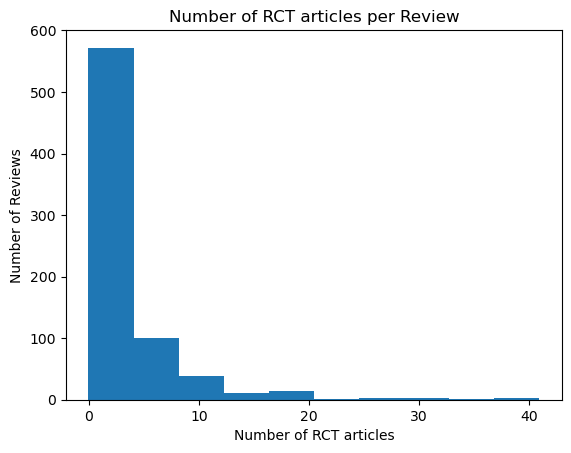

In [11]:
filtered_data = pd.read_json("./cochrane_review_data_filtered_mismatched_studies.jsonl", lines=True)

# create a histogram of the number of inputs per review
import matplotlib.pyplot as plt

plt.hist(filtered_data["NumInputs"], align="left")
plt.xlabel("Number of RCT articles")
plt.ylabel("Number of Reviews")
plt.title("Number of RCT articles per Review")

plt.show()

# Final Review Data

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cochrane_data_file_path = "./cochrane_review_data_cleaned.jsonl"
df = pd.read_json(cochrane_data_file_path, orient="records", lines=True)

In [32]:
print(f"Number of Reviews in Data: {len(df)}")

Number of Reviews in Data: 629


In [11]:
# STATISTICS
# get the average number of inputs per review
average_num_inputs = df["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = df["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = df["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

average number of inputs per review: 4.874403815580286
maximum number of inputs per review: 43
minimum number of inputs per review: 2


In [23]:
# Collect unique abstracts by PMID
seen_pmids = set()
unique_abstracts = []

for inputs_list in df["Inputs"]:
    for inp in inputs_list:
        pmid = inp.get("PMID")        # get the PMID
        abstract = inp.get("Abstract")  # get the abstract
        # Include only if PMID is not seen and abstract is not None
        if pmid not in seen_pmids:
            seen_pmids.add(pmid)
            unique_abstracts.append(abstract)

# Count words in each unique abstract
abstract_word_counts = [len(abstract.split()) for abstract in unique_abstracts]

# Compute average
average_words = sum(abstract_word_counts) / len(abstract_word_counts)

print(f"Number of unique abstracts included: {len(abstract_word_counts)}")
print(f"Average abstract length (words): {average_words:.2f}")

Number of unique abstracts included: 3038
Average abstract length (words): 230.95


In [16]:
# average of abstract length of included trials (number of words)
all_abstracts = [
    input["Abstract"]
    for inputs_list in df["Inputs"]
    for input in inputs_list
]

# Count words in each abstract
abstract_word_counts = [len(abstract.split()) for abstract in all_abstracts]

average_words = sum(abstract_word_counts) / len(abstract_word_counts)
print(f"Number of abstracts included: {len(abstract_word_counts)}")

print(f"Average abstract length (words): {average_words}")

Number of abstracts included: 3066
Average abstract length (words): 230.84996738421395


In [33]:
# how many reviews with numinputs 10 or greater
count = (df["NumInputs"] >= 10).sum()
print(count)


57


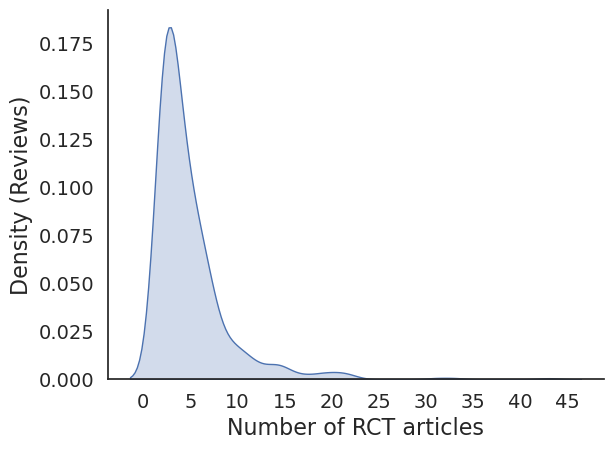

In [22]:
# set seaborn style
sns.set(style="white")

# create density plot
sns.kdeplot(
    data=df,
    x="NumInputs",
    fill=True
)

# sns.displot(data=df,
#     x="NumInputs", kde=True) 

# axis labels with larger font
plt.xlabel("Number of RCT articles", fontsize=16)
plt.ylabel("Density (Reviews)", fontsize=16)

# increase tick label font size
plt.xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# remove top and right spines
sns.despine(top=True, right=True)

plt.savefig("num_clinical_trials_per_review.pdf", bbox_inches="tight")

plt.show()

# Final Data after Question Generation

In [4]:
import pandas as pd

extracted_df = pd.read_json("../code/outputs/extracted_text/qwen3_thinking-4B/extracted_interventions_conditions.json")
questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/cochrane_review_data_final_with_questions.json")

In [35]:
print(f"number of reviews (total): {len(extracted_df)}")

number of reviews (total): 629


In [36]:
# find how many reviews had ExtractedText field of a dict with both values of "intervention" and "condintion" being null
num_null = 0
for _, row in extracted_df.iterrows():
    extracted_text = row["ExtractedText"]
    if extracted_text.get("intervention") is None or extracted_text.get("condition") is None:
        num_null += 1
print(f"Number of reviews with either intervention or condition as null: {num_null}")

Number of reviews with either intervention or condition as null: 261


In [37]:
len(extracted_df) - num_null

368

In [38]:
print(f"number of reviews with questions: {len(questions_df)}")

number of reviews with questions: 368


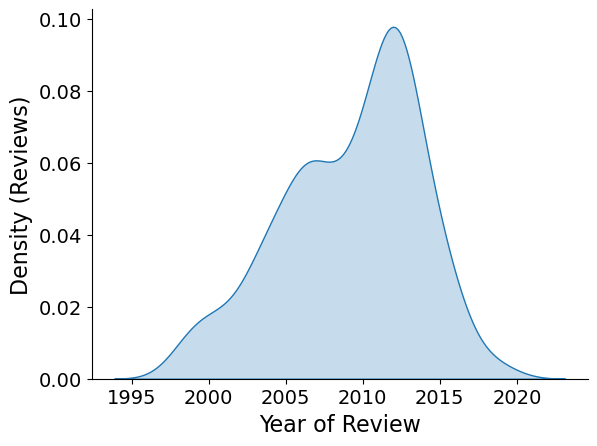

In [9]:
# create density plot
sns.kdeplot(
    data=questions_df,
    x="Year",
    fill=True
)

# axis labels with larger font
plt.xlabel("Year of Review", fontsize=16)
plt.ylabel("Density (Reviews)", fontsize=16)

# increase tick label font size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# remove top and right spines
sns.despine(top=True, right=True)

plt.show()

<Axes: xlabel='Year', ylabel='Count'>

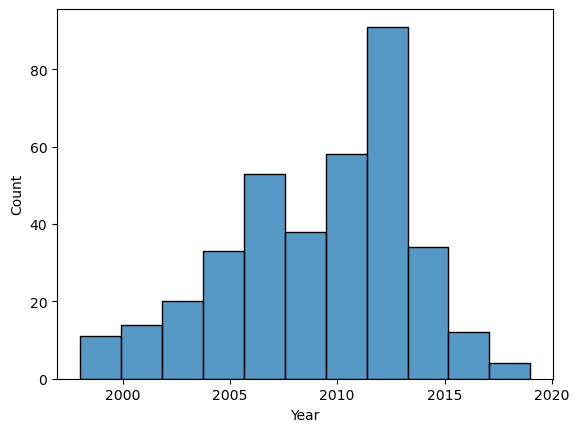

In [10]:
sns.histplot(data=questions_df, x="Year")

In [52]:
# how many reviews with numinputs 10 or greater
count = (questions_df["NumInputs"] >= 10).sum()
print(count)

31


In [ ]:
# get the average MedReadMe scores across all reviews
positive_scores = []
negative_scores = []
sum_scores = {
    "effectiveness": 0,
    "efficacy": 0,
    "safety": 0,
    "studies": 0,
    "timepressure": 0,
    "cost": 0,
    "family": 0,
    "friend": 0,
    "testimonials": 0,
    "journals": 0,
    "ai": 0,
    "doctor": 0,
    "multiturn": 0
}
for _, row in questions_df.iterrows():
    medreadme_scores = row["MedReadMeScores"]
    for category, scores in medreadme_scores.items():
        positive_score = scores["positive_question"]
        negative_score = scores["negative_question"]
        positive_scores.append(positive_score)
        negative_scores.append(negative_score)

        average_score = (positive_score + negative_score) / 2
        sum_scores[category] += average_score

num_reviews = len(questions_df)
average_scores = {category: total / num_reviews for category, total in sum_scores.items()}
print("Average MedReadMe (medical jargon) scores (range 1-6) across all reviews:")
for category, avg_score in average_scores.items():
    print(f"{category}: {avg_score:.2f}")

all_scores = positive_scores + negative_scores
print(f"overall average: {sum(all_scores)/len(all_scores):.2f}")
print(f"positive questions average: {sum(positive_scores)/len(positive_scores):.2f}")
print(f"negative questions average: {sum(negative_scores)/len(negative_scores):.2f}")


Average MedReadMe (medical jargon) scores (range 1-6) across all reviews:
effectiveness1: 4.56
effectiveness2: 4.57
safety: 4.59
studies: 4.52
timepressure: 4.44
cost: 4.53
family: 4.42
friend: 4.42
testimonials: 4.46
journals: 4.47
ai: 4.50
doctor: 4.40
multiturn: 4.56
overall average: 4.49
positive questions average: 4.50
negative questions average: 4.49


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create long-form DataFrame
df = pd.DataFrame({
    "score": positive_scores + negative_scores
})

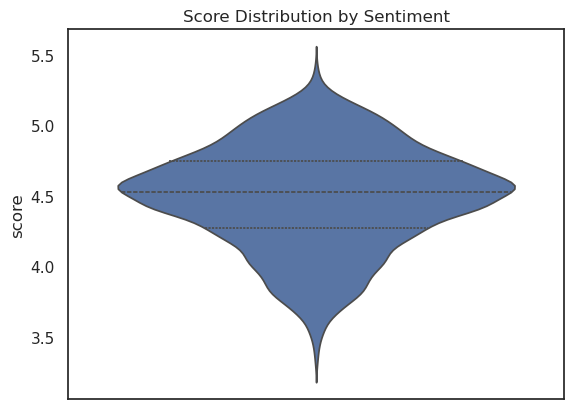

In [42]:
sns.violinplot(y="score", data=df, inner="quartile")
plt.title("Score Distribution by Sentiment")
plt.show()

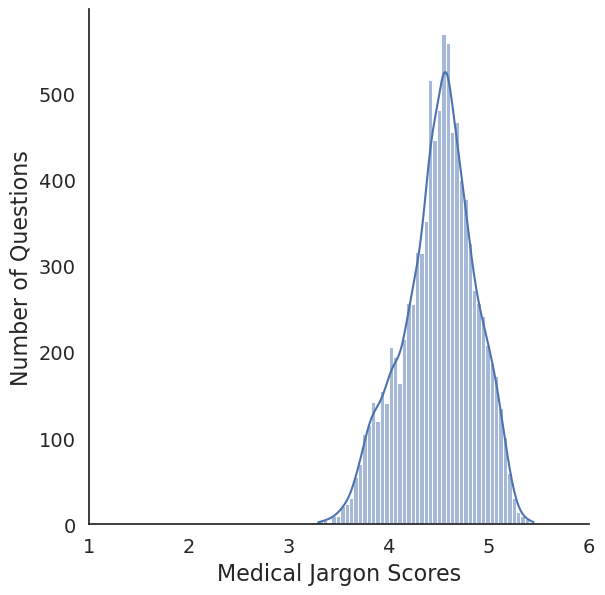

In [43]:
# set seaborn style
sns.set(style="white")

# create density plot
# sns.kdeplot(
#     data=df,
#     x="score",
#     fill=True
# )

# sns.displot(
#     data=df,
#     x="score", hue="type",
#     kind="kde", height=6,
#     multiple="fill", clip=(0, None),
#     palette="ch:rot=-.25,hue=1,light=.75",
# )

sns.displot(data=df,
    x="score", kde=True, height=6) 

# axis labels with larger font
plt.xlabel("Medical Jargon Scores", fontsize=16)
plt.ylabel("Number of Questions", fontsize=16)

# increase tick label font size
plt.xticks([1, 2, 3, 4, 5, 6])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# remove top and right spines
sns.despine(top=True, right=True)

plt.show()

In [54]:
# STATISTICS
# get the average number of inputs per review
average_num_inputs = questions_df["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = questions_df["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = questions_df["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

average number of inputs per review: 4.782608695652174
maximum number of inputs per review: 33
minimum number of inputs per review: 2


In [55]:
# Collect unique abstracts by PMID
seen_pmids = set()
unique_abstracts = []

for inputs_list in questions_df["Inputs"]:
    for inp in inputs_list:
        pmid = inp.get("PMID")        # get the PMID
        abstract = inp.get("Abstract")  # get the abstract
        # Include only if PMID is not seen and abstract is not None
        if pmid not in seen_pmids:
            seen_pmids.add(pmid)
            unique_abstracts.append(abstract)

# Count words in each unique abstract
abstract_word_counts = [len(abstract.split()) for abstract in unique_abstracts]

# Compute average
average_words = sum(abstract_word_counts) / len(abstract_word_counts)

print(f"Number of unique abstracts included: {len(abstract_word_counts)}")
print(f"Average abstract length (words): {average_words:.2f}")

Number of unique abstracts included: 1753
Average abstract length (words): 231.47


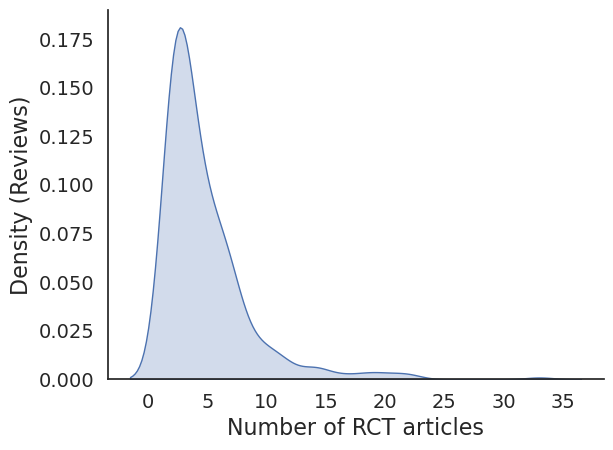

In [56]:
# set seaborn style
sns.set(style="white")

# create density plot
sns.kdeplot(
    data=questions_df,
    x="NumInputs",
    fill=True
)

# sns.displot(data=df,
#     x="NumInputs", kde=True) 

# axis labels with larger font
plt.xlabel("Number of RCT articles", fontsize=16)
plt.ylabel("Density (Reviews)", fontsize=16)

# increase tick label font size
plt.xticks([0, 5, 10, 15, 20, 25, 30, 35])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# remove top and right spines
sns.despine(top=True, right=True)

plt.show()

# Reviews with Simple/General Topic Types

In [12]:
import pandas as pd

general_reviews = pd.read_json("../code/outputs/filtering_data/general_topic_type_cochrane_review_data_qwen3thinking_4B.jsonl", lines=True)

for _, row in general_reviews.iterrows():
    review_title = row["ReviewTitle"]
    print(review_title)

Oral steroids for adhesive capsulitis
Intranasal corticosteroids for nasal airway obstruction in children with moderate to severe adenoidal hypertrophy 
Topical nasal steroids for intermittent and persistent allergic rhinitis in children
Routine prophylactic drugs in normal labour for reducing gastric aspiration and its effects 
Directly observed therapy for treating tuberculosis
Alcoholics Anonymous and other 12‐step programmes for alcohol dependence
Inositol for depressive disorders
Fluids and diuretics for acute ureteric colic
Probiotics for the treatment of bacterial vaginosis
Prophylactic vitamin K for vitamin K deficiency bleeding in neonates
Sensory stimulation for brain injured individuals in coma or vegetative state
Surgical repair of spontaneous perineal tears that occur during childbirth versus no intervention 
Continuous positive airway pressure delivery interfaces for obstructive sleep apnoea
Physical methods for preventing deep vein thrombosis in stroke
Psychosocial inter

## Categories of Conditions

In [7]:
import pandas as pd

questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/cochrane_review_data_final_with_questions.json")
conditions = []
for _, row in questions_df.iterrows():
    extracted_text = row["ExtractedText"]
    condition = extracted_text.get("condition")
    conditions.append(condition)

conditions_df = pd.DataFrame(conditions)
conditions_df.to_csv("cochrane_review_conditions.csv", index=False, header=False)

In [8]:
import pandas as pd

condition_categories_df = pd.read_csv("cochrane_review_categorized_conditions.csv")

# get count of each category
category_counts = condition_categories_df["category"].value_counts()
print(category_counts)

category
Neurology & Pain                       67
Respiratory                            40
Pregnancy, Childbirth & Gynaecology    36
Musculoskeletal & Orthopaedic          35
Oncology                               35
Gastrointestinal & Hepatology          33
Infectious Diseases & Dermatology      33
Mental Health & Behavioural            32
Ear, Nose, Throat & Dental             15
Cardiovascular                         13
Endocrine & Metabolic                  11
Ophthalmology                           8
Urology & Nephrology                    5
Other / General                         5
Name: count, dtype: int64


In [17]:
questions_df = pd.read_json("../code/outputs/questions/qwen3_thinking-4B/cochrane_review_data_final_with_questions.json")

identifiers = []
for _, row in questions_df.iterrows():
    review_id = row["ReviewID"]
    doi = row["DOI"]

    identifiers.append((review_id, doi))

In [10]:
# add the identifiers to conditoin_categories_df by order
condition_categories_df["ReviewID"] = [id[0] for id in identifiers]
condition_categories_df["DOI"] = [id[1] for id in identifiers]

In [11]:
condition_categories_df.head()

,condition,category,ReviewID,DOI
0,fatigue in multiple sclerosis,Neurology & Pain,CD002818,10.1002/14651858.CD002818.pub2
1,vertigo in Ménière's disease,"Ear, Nose, Throat & Dental",CD008234,10.1002/14651858.CD008234.pub2
2,rheumatoid arthritis,Musculoskeletal & Orthopaedic,CD008341,10.1002/14651858.CD008341
3,rheumatoid arthritis,Musculoskeletal & Orthopaedic,CD003685,10.1002/14651858.CD003685.pub2
4,liver metastases from colorectal cancer,Oncology,CD007045,10.1002/14651858.CD007045.pub2


In [12]:
# save the condition_categories_df to a csv file
condition_categories_df.to_csv("cochrane_review_categorized_conditions.csv", index=False)

In [18]:
# add the category from condition_categories_df to questions_df by merging on ReviewID
questions_df = questions_df.merge(condition_categories_df[["ReviewID", "category"]], on="ReviewID", how="left")
# rename the category column to ConditionCategory
questions_df = questions_df.rename(columns={"category": "ConditionCategory"})

In [19]:
questions_df.head()

,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs,Year,Keywords,NumIncludedStudies,ExtractedText,Questions,MedReadMeScores,ConditionCategory
0,10.1002/14651858.CD002818.pub2,CD002818,Amantadine for fatigue in multiple sclerosis,"[{'heading': 'Background', 'text': 'Fatigue is...","[{'ReviewID': 'CD002818', 'PMID': 14759641, 'T...",5,2007,"Amantadine [adverse effects, *therapeutic use]...",5,"{'intervention': 'amantadine', 'condition': 'f...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.524...,Neurology & Pain
1,10.1002/14651858.CD008234.pub2,CD008234,Intratympanic gentamicin for Ménière's disease...,"[{'heading': 'Background', 'text': 'Ménière's ...","[{'ReviewID': 'CD008234', 'PMID': 15072419, 'T...",2,2011,Anti-Bacterial Agents [*administration & dosag...,2,"{'intervention': 'intratympanic gentamicin', '...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.982...,"Ear, Nose, Throat & Dental"
2,10.1002/14651858.CD008341,CD008341,Golimumab for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Golimumab ...","[{'ReviewID': 'CD008341', 'PMID': 18383539, 'T...",4,2010,"Adult; Antibodies, Monoclonal [*therapeutic us...",4,"{'intervention': 'golimumab', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.672...,Musculoskeletal & Orthopaedic
3,10.1002/14651858.CD003685.pub2,CD003685,Rofecoxib for rheumatoid arthritis,"[{'heading': 'Background', 'text': 'Editor's n...","[{'ReviewID': 'CD003685', 'PMID': 10566565, 'T...",2,2005,"Anti‐Inflammatory Agents, Non‐Steroidal [adver...",2,"{'intervention': 'rofecoxib', 'condition': 'rh...",{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.667...,Musculoskeletal & Orthopaedic
4,10.1002/14651858.CD007045.pub2,CD007045,Selective internal radiation therapy for liver...,"[{'heading': 'Background', 'text': 'Liver meta...","[{'ReviewID': 'CD007045', 'PMID': 11843249, 'T...",2,2009,*Colorectal Neoplasms; *Liver Neoplasms [drug ...,2,{'intervention': 'selective internal radiation...,{'effectiveness1': {'positive_question': 'How ...,{'effectiveness1': {'positive_question': 4.774...,Oncology


In [21]:
# save as json 
# questions_df to list of dicts and save to json file
data = questions_df.to_dict(orient="records")

import json

with open("../code/outputs/questions/qwen3_thinking-4B/cochrane_review_data_final_with_questions.json", "w", encoding='utf-8') as file:
    json.dump(data, file, indent=4)


In [ ]:
# def add_condition_category(model_name):
#     responses_df = pd.read_json(f"../code/outputs/responses/{model_name}/question_responses.json")
#     condition_categories_df = pd.read_csv("cochrane_review_categorized_conditions.csv")

#     # add the category from condition_categories_df to responses_df by merging on ReviewID
#     responses_df = responses_df.merge(condition_categories_df[["ReviewID", "category"]], on="ReviewID", how="left")
#     # rename the category column to ConditionCategory
#     responses_df = responses_df.rename(columns={"category": "ConditionCategory"})

#     # save as json 
#     # responses_df to list of dicts and save to json file
#     data = responses_df.to_dict(orient="records")

#     with open(f"../code/outputs/responses/{model_name}/question_responses.json", "w", encoding='utf-8') as file:
#         json.dump(data, file, indent=4)

In [ ]:
# models = ["api-llama3.3", "api-llama4", "claude_4.5_sonnet", "gpt-5.1", "huatuo-7B", "huatuo-8B", "qwen3_thinking-4B", "qwen3-4B", "qwen3-30B"]

# for model in models:
#     add_condition_category(model)